## File 2: Phân Tích Lỗi Phân Loại & Các Phương Pháp Tiền Xử Lý
Phân tích ảnh bị phân loại sai và so sánh 10 phương pháp tiền xử lý.

### 1. Import thư viện

In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os, shutil, cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy import stats
from tqdm import tqdm


## 2. Load mô hình và cấu hình

In [2]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 128
NUM_CLASSES = 5
class_names = ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant', 'Normal']

# Load model 
model = load_model('../Model/best_model.keras')

test_dir = '../DataSet/test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=False
)


Found 1649 images belonging to 5 classes.


## 3. Lấy ảnh bị phân loại sai & lưu vào thư mục riêng

In [3]:
test_generator.reset()
n_samples    = test_generator.samples
pred_probs   = model.predict(test_generator, verbose=1)[:n_samples]
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes[:n_samples]
filenames    = test_generator.filenames

misclassified_idx = np.where(pred_classes != true_classes)[0]
print(f"Số mẫu dự đoán sai: {len(misclassified_idx)}")

# Thu thập thông tin
misclassified_samples = []
for i in misclassified_idx:
    misclassified_samples.append({
        "file":       filenames[i],
        "true_label": class_names[true_classes[i]],
        "pred_label": class_names[pred_classes[i]],
        "confidence": float(np.max(pred_probs[i]))
    })


 4/13 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

KeyboardInterrupt: 

In [ ]:
# Lưu ảnh vào thư mục theo class thật
output_dir = "../Output/Misclassified samples"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

for i in misclassified_idx:
    true_label = class_names[true_classes[i]]
    pred_label = class_names[pred_classes[i]]
    class_dir  = os.path.join(output_dir, true_label)
    os.makedirs(class_dir, exist_ok=True)

    src      = os.path.join(test_generator.directory, filenames[i])
    filename = f"pred_{pred_label}__{os.path.basename(filenames[i])}"
    shutil.copy(src, os.path.join(class_dir, filename))

print("Đã lưu ảnh vào các thư mục theo class thật:")
for label in class_names:
    class_dir = os.path.join(output_dir, label)
    if os.path.exists(class_dir):
        print(f"  {label}: {len(os.listdir(class_dir))} ảnh")


## 4. Hiển thị mẫu ảnh bị phân loại sai

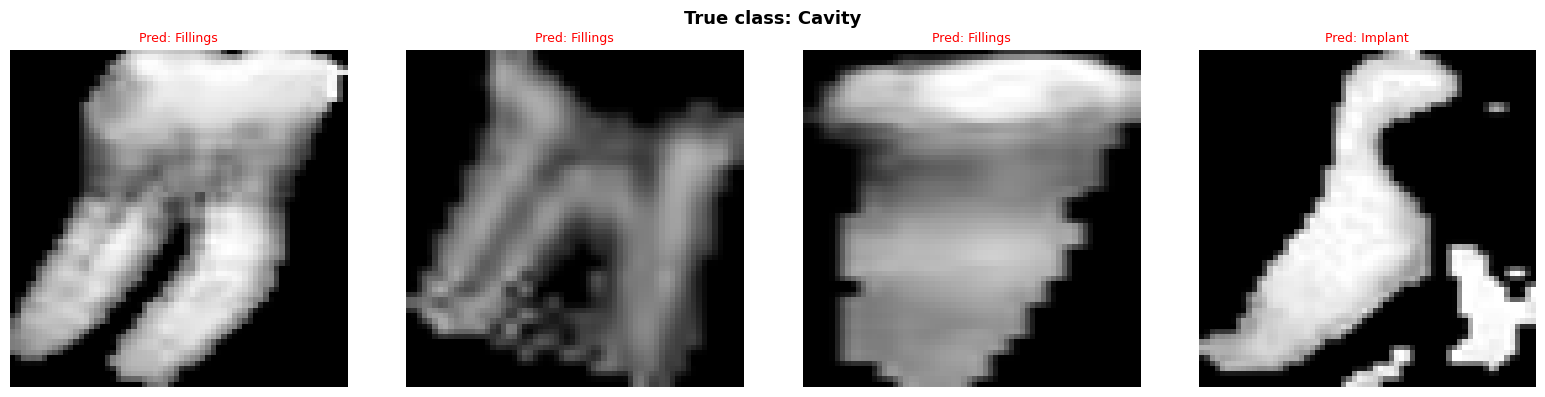

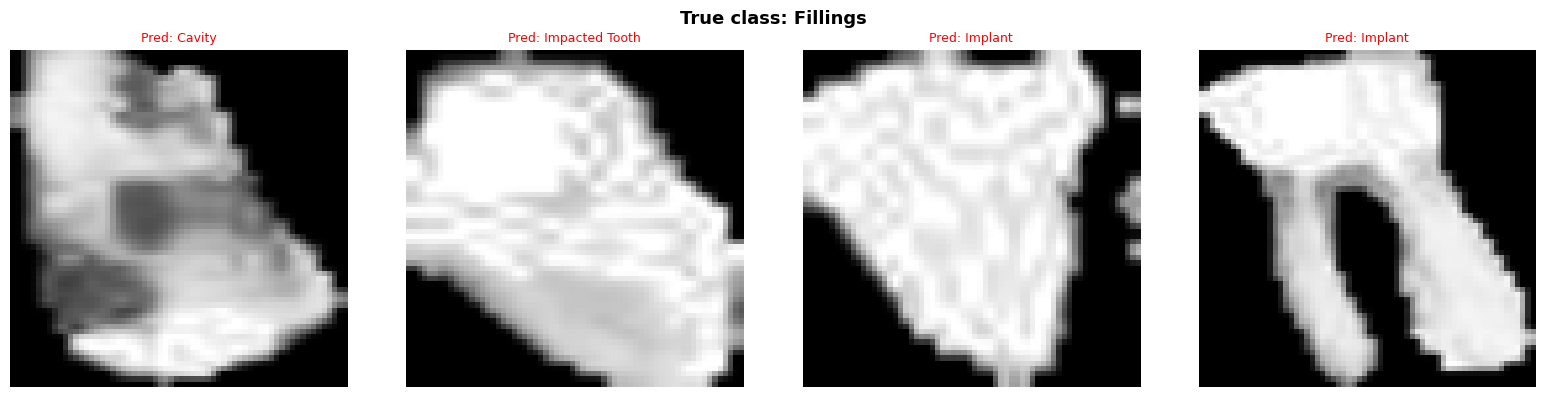

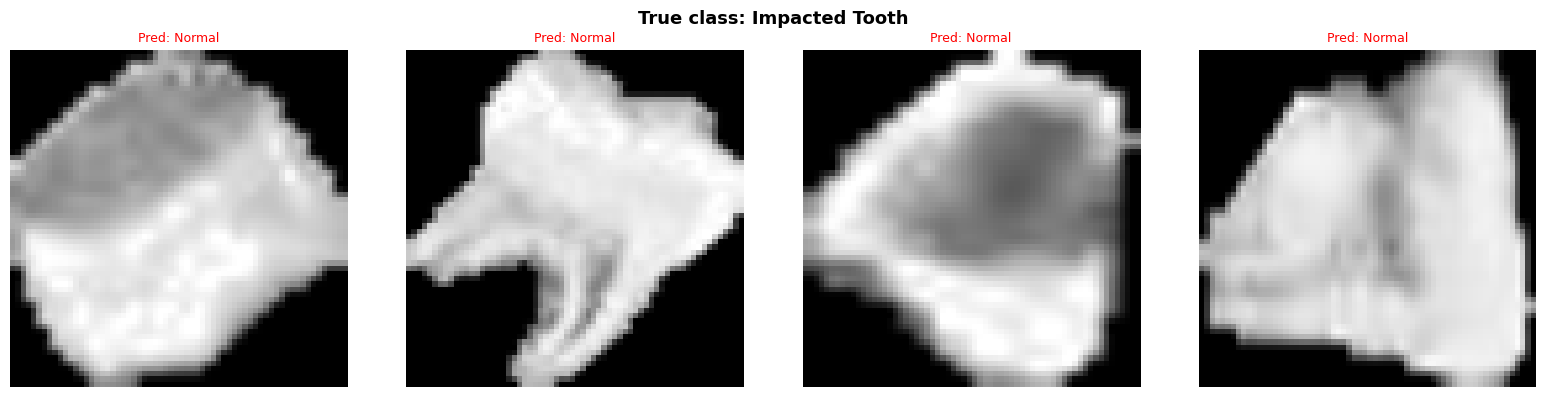

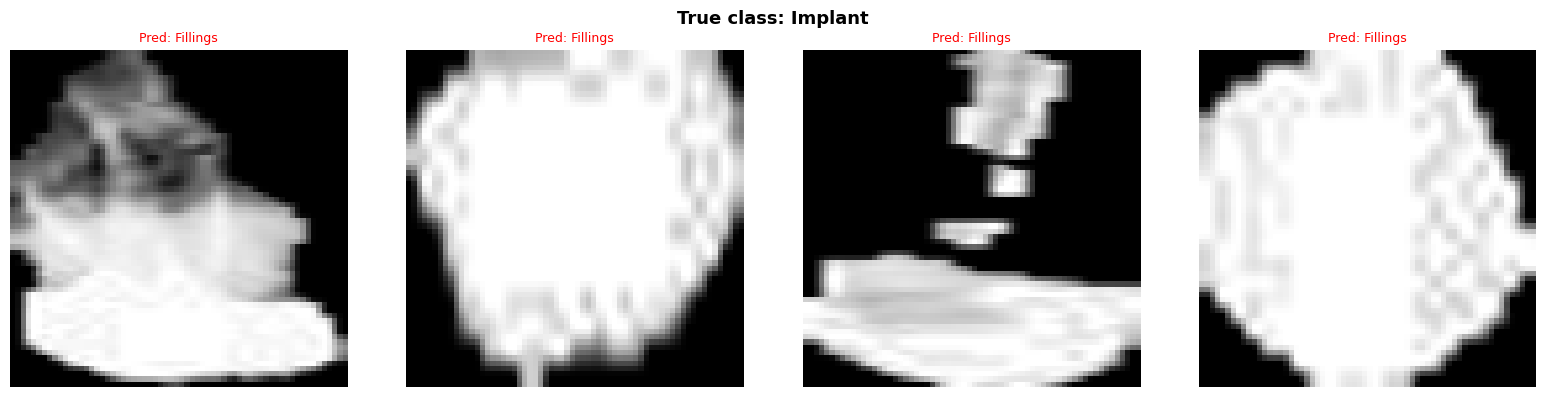

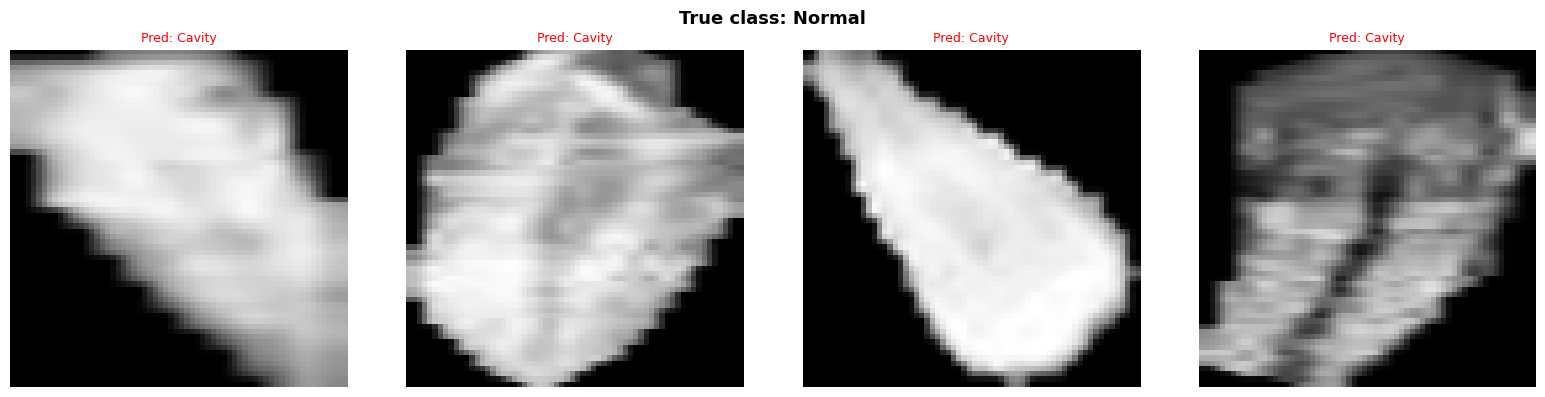

In [4]:
N_DISPLAY = 4
misclassified_dir = "../Output/Misclassified samples"

for true_class in os.listdir(misclassified_dir):
    class_path = os.path.join(misclassified_dir, true_class)
    if not os.path.isdir(class_path):
        continue
    files = os.listdir(class_path)[:N_DISPLAY]
    if not files:
        continue

    fig, axes = plt.subplots(1, len(files), figsize=(4 * len(files), 4))
    if len(files) == 1:
        axes = [axes]
    fig.suptitle(f"True class: {true_class}", fontsize=13, fontweight='bold')

    for ax, fname in zip(axes, files):
        img = mpimg.imread(os.path.join(class_path, fname))
        pred_class = fname.split("pred_")[1].split("__")[0]
        ax.imshow(img); ax.set_title(f"Pred: {pred_class}", color='red', fontsize=9); ax.axis('off')

    plt.tight_layout(); plt.show()


## 5. Phân tích đặc trưng ảnh sai (brightness, contrast, blur...)

In [5]:
def analyze_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    hist_norm = hist / (hist.sum() + 1e-10)
    return {
        'brightness': np.mean(gray),
        'contrast':   np.std(gray),
        'width': w, 'height': h,
        'resolution': w * h,
        'blur_score': cv2.Laplacian(gray, cv2.CV_64F).var(),
        'entropy':    -np.sum(hist_norm * np.log2(hist_norm + 1e-10)),
    }


In [6]:
wrong_samples = []
for true_class in os.listdir(misclassified_dir):
    class_path = os.path.join(misclassified_dir, true_class)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if not img_file.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff')):
            continue
        features = analyze_image(os.path.join(class_path, img_file))
        if features:
            features['filename']    = img_file
            features['true_class']  = true_class
            features['folder_path'] = class_path
            wrong_samples.append(features)

df_wrong = pd.DataFrame(wrong_samples)

# Trích pred_class từ tên file
def extract_pred_class(filename):
    if 'pred_' in filename:
        pred = filename.split('_')[1]
        return pred.split('__')[0] if '__' in pred else pred
    return 'Unknown'

df_wrong['pred_class'] = df_wrong['filename'].apply(extract_pred_class)
df_wrong.to_csv('../Output/Results/misclassified_analysis.csv', index=False)
print(df_wrong[['filename', 'true_class', 'pred_class', 'brightness', 'contrast', 'blur_score']].head())


                                            filename true_class pred_class  \
0  pred_Fillings__0009_jpg.rf.957a0a16c5101765b06...     Cavity   Fillings   
1  pred_Fillings__0669_jpg.rf.f1e2059357f8ba42a2c...     Cavity   Fillings   
2  pred_Fillings__0905_jpg.rf.93c5b0e9d232f394f6c...     Cavity   Fillings   
3  pred_Implant__0180_jpg.rf.f74c66bb6212781fc6e6...     Cavity    Implant   
4  pred_Normal__0038_jpg.rf.e13603a0be37e61c53a3b...     Cavity     Normal   

   brightness    contrast   blur_score  
0  104.835693   92.841826  1236.021913  
1   63.173096   56.932805   205.358688  
2  103.650635   80.700369   630.599424  
3   80.929199  104.691704  2594.344321  
4  103.587158   83.588573   543.915563  


## 6. Định nghĩa 10 phương pháp tiền xử lý

In [7]:
def preprocess_method_1_original(image_path):
    # Original chỉ resize và chuẩn hóa
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

def _apply_clahe(image_path, clip):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB) / 255.0

def preprocess_method_2_clahe(image_path):    return _apply_clahe(image_path, 3.0)
def preprocess_method_3_clahe_light(image_path): return _apply_clahe(image_path, 1.5)
def preprocess_method_4_clahe_strong(image_path): return _apply_clahe(image_path, 5.0)

def preprocess_method_5_histogram_equalization(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    yuv[:, :, 0] = cv2.equalizeHist(yuv[:, :, 0])
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB) / 255.0

def preprocess_method_6_gamma_correction(image_path, gamma=1.2):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return np.power(img, gamma)

def preprocess_method_7_sharpen(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    kernel = np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]])
    return cv2.filter2D(img, -1, kernel) / 255.0

def preprocess_method_8_brightness_boost(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.convertScaleAbs(img, alpha=1.2, beta=20) / 255.0

def preprocess_method_9_adaptive_threshold(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
    return cv2.cvtColor(thresh, cv2.COLOR_GRAY2RGB) / 255.0

def preprocess_method_10_unsharp_mask(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gaussian = cv2.GaussianBlur(img, (0, 0), 2.0)
    return cv2.addWeighted(img, 1.5, gaussian, -0.5, 0) / 255.0

preprocessing_methods = {
    '1_Original':         preprocess_method_1_original,
    '2_CLAHE_3.0':        preprocess_method_2_clahe,
    '3_CLAHE_1.5':        preprocess_method_3_clahe_light,
    '4_CLAHE_5.0':        preprocess_method_4_clahe_strong,
    '5_HistEq':           preprocess_method_5_histogram_equalization,
    '6_Gamma_1.2':        preprocess_method_6_gamma_correction,
    '7_Sharpen':          preprocess_method_7_sharpen,
    '8_Brightness':       preprocess_method_8_brightness_boost,
    '9_AdaptiveThresh':   preprocess_method_9_adaptive_threshold,
    '10_UnsharpMask':     preprocess_method_10_unsharp_mask,
}


## 7. Đánh giá tất cả phương pháp trên ảnh sai

In [11]:
def evaluate_all_methods(df, model, class_names, batch_size=32):
    results_all = {}
    image_paths  = [os.path.join(r['folder_path'], r['filename']) for _, r in df.iterrows()]
    row_indices  = list(df.index)

    for method_name, preprocess_func in preprocessing_methods.items():
        print(f"\nĐánh giá: {method_name}")
        results = []
        for i in tqdm(range(0, len(image_paths), batch_size)):
            batch_paths   = image_paths[i:i+batch_size]
            batch_indices = row_indices[i:i+batch_size]
            batch_images, valid_idx = [], []
            for j, path in enumerate(batch_paths):
                img = preprocess_func(path)
                if img is not None:
                    batch_images.append(img); valid_idx.append(batch_indices[j])
            if batch_images:
                preds = model.predict(np.array(batch_images), verbose=0)
                for k, pred in enumerate(preds):
                    row = df.iloc[valid_idx[k]]
                    pc  = class_names[np.argmax(pred)]
                    results.append({
                        'filename': row['filename'], 'true_class': row['true_class'],
                        'original_pred': row['pred_class'], 'new_prediction': pc,
                        'confidence': float(np.max(pred)), 'is_correct': pc == row['true_class'],
                        'brightness': row['brightness'], 'contrast': row['contrast'],
                        'blur_score': row['blur_score']
                    })
        rdf = pd.DataFrame(results)
        correct, total = rdf['is_correct'].sum(), len(rdf)
        results_all[method_name] = {'df': rdf, 'correct': correct, 'total': total, 'accuracy': correct/total*100}
        rdf.to_csv(f'../Output/Results/results_{method_name}.csv', index=False)
        print(f"  {correct}/{total} đúng ({correct/total*100:.2f}%)")
    return results_all


In [12]:
df_original = pd.read_csv('../Output/Results/misclassified_analysis.csv')
df_original['pred_class'] = df_original['filename'].apply(extract_pred_class)

results_all = evaluate_all_methods(df_original, model, class_names, batch_size=32)

comparison_table = [{'Method': m, 'Fixed': r['correct'], 'Total': r['total'],
                     'Accuracy': f"{r['accuracy']:.2f}%"} for m, r in results_all.items()]
comparison_df = pd.DataFrame(comparison_table).sort_values('Fixed', ascending=False)
print(comparison_df.to_string(index=False))



Đánh giá: 1_Original


100%|██████████| 4/4 [00:02<00:00,  1.50it/s]


  19/120 đúng (15.83%)

Đánh giá: 2_CLAHE_3.0


100%|██████████| 4/4 [00:02<00:00,  1.35it/s]


  54/120 đúng (45.00%)

Đánh giá: 3_CLAHE_1.5


...

  48/120 đúng (40.00%)

Đánh giá: 9_AdaptiveThresh


100%|██████████| 4/4 [00:02<00:00,  1.59it/s]


  61/120 đúng (50.83%)

Đánh giá: 10_UnsharpMask


100%|██████████| 4/4 [00:02<00:00,  1.46it/s]

  8/120 đúng (6.67%)
          Method  Fixed  Total Accuracy
9_AdaptiveThresh     61    120   50.83%
     4_CLAHE_5.0     57    120   47.50%
     2_CLAHE_3.0     54    120   45.00%
    8_Brightness     48    120   40.00%
        5_HistEq     42    120   35.00%
     3_CLAHE_1.5     31    120   25.83%
       7_Sharpen     24    120   20.00%
      1_Original     19    120   15.83%
     6_Gamma_1.2     19    120   15.83%
  10_UnsharpMask      8    120    6.67%


## 8. Confusion Matrix cho từng phương pháp

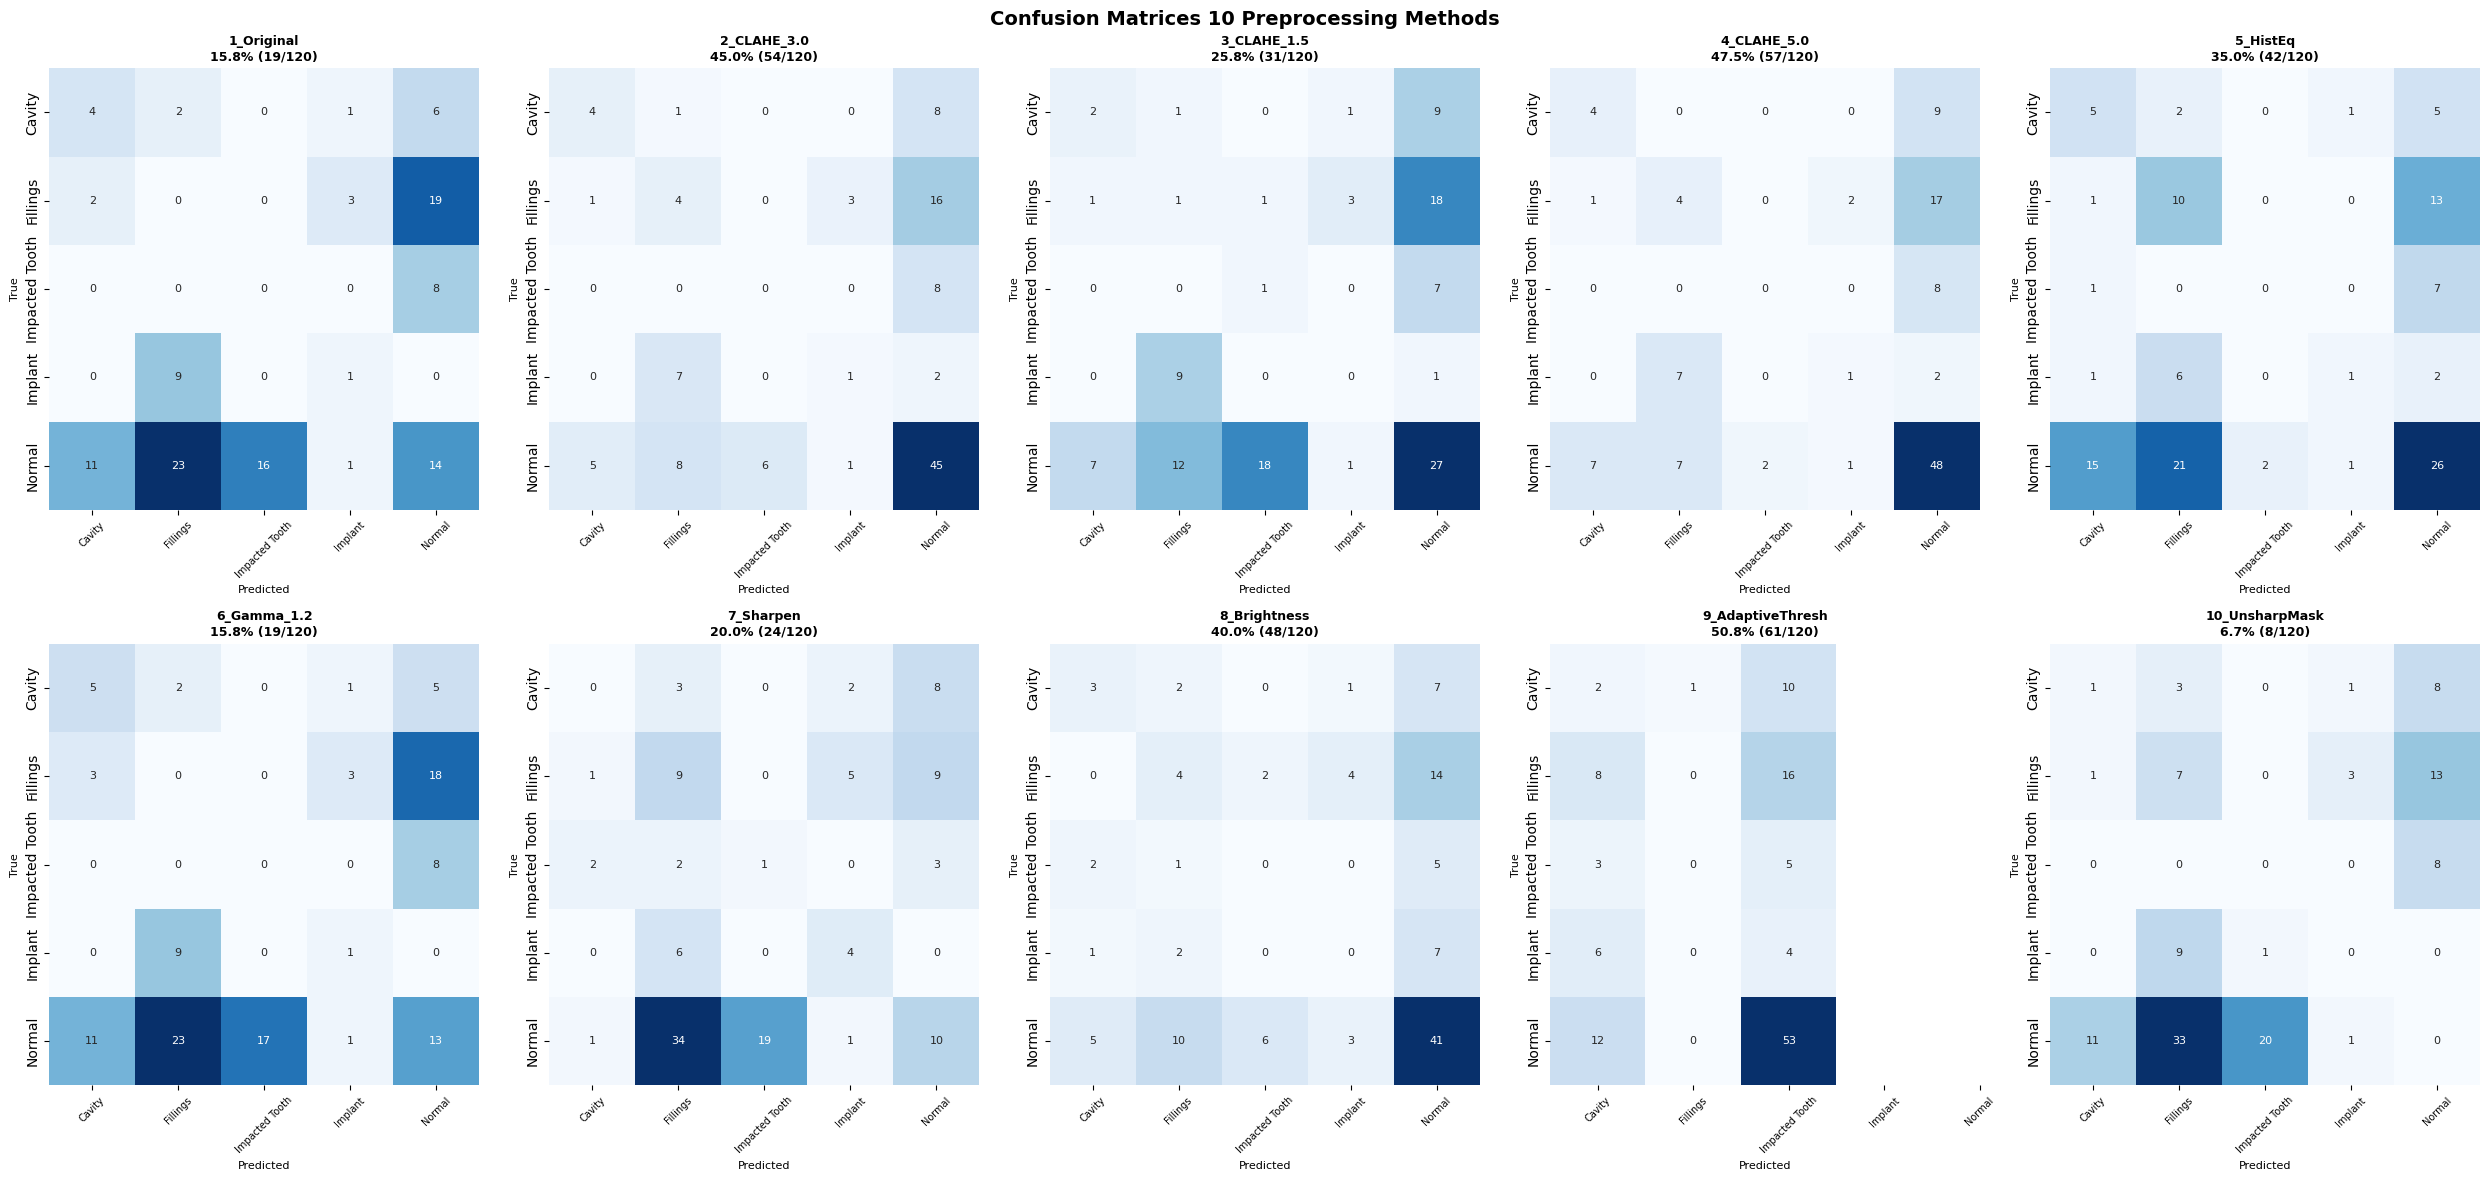

In [13]:
methods_files = {m: f'../Output/Results/results_{m}.csv' for m in preprocessing_methods}
all_results = {m: pd.read_csv(p) for m, p in methods_files.items() if os.path.exists(p)}

fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.ravel()

for idx, (method_name, rdf) in enumerate(all_results.items()):
    correct  = rdf['is_correct'].sum()
    total    = len(rdf)
    accuracy = correct / total * 100
    cm = pd.crosstab(rdf['true_class'], rdf['new_prediction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar=False, annot_kws={'size': 8})
    axes[idx].set_title(f'{method_name}\n{accuracy:.1f}% ({correct}/{total})', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=8); axes[idx].set_ylabel('True', fontsize=8)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=7)

for idx in range(len(all_results), 10):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices 10 Preprocessing Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Output/Results/all_10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Phân tích từng lớp & tìm phương pháp tốt nhất

In [14]:
class_analysis = {cn: {} for cn in class_names}
for method_name, rdf in all_results.items():
    for cn in class_names:
        cd = rdf[rdf['true_class'] == cn]
        if len(cd) > 0:
            correct = cd['is_correct'].sum()
            class_analysis[cn][method_name] = {
                'correct': correct, 'total': len(cd),
                'accuracy': correct / len(cd) * 100
            }

best_methods = {}
for cn in class_names:
    best_method  = max(class_analysis[cn], key=lambda m: class_analysis[cn][m]['accuracy'])
    best_methods[cn] = {**class_analysis[cn][best_method], 'method': best_method}
    print(f"{cn}: best = {best_method}  ({best_methods[cn]['correct']}/{best_methods[cn]['total']} = {best_methods[cn]['accuracy']:.1f}%)")


Cavity: best = 5_HistEq  (5/13 = 38.5%)
Fillings: best = 5_HistEq  (10/24 = 41.7%)
Impacted Tooth: best = 3_CLAHE_1.5  (1/8 = 12.5%)
Implant: best = 7_Sharpen  (4/10 = 40.0%)
Normal: best = 9_AdaptiveThresh  (53/65 = 81.5%)


## 10. Trực quan hóa so sánh accuracy theo lớp

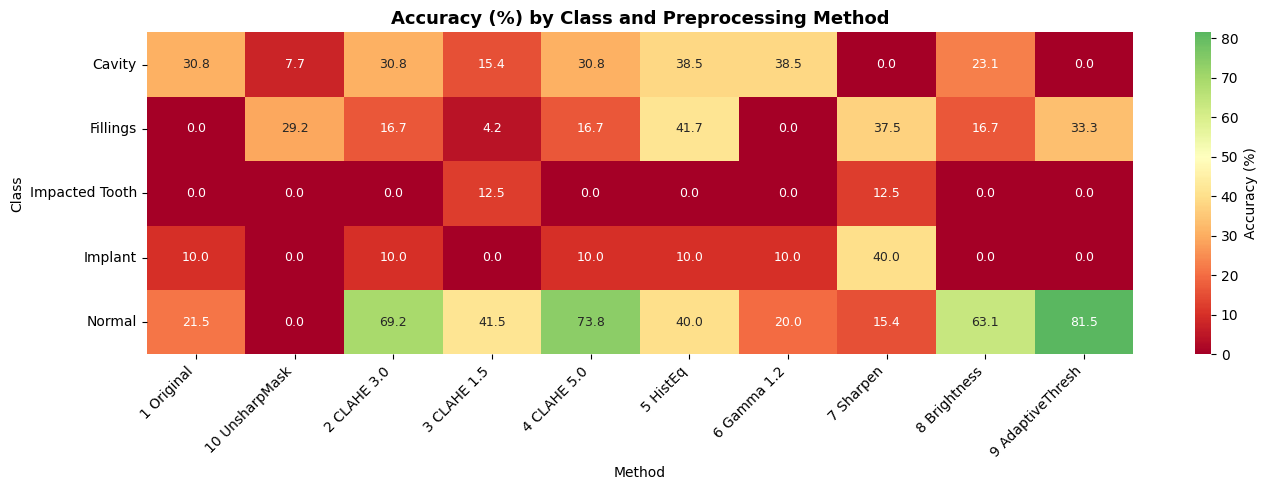

In [16]:
comparison_data = []
for cn in class_names:
    for m in all_results:
        if m in class_analysis[cn]:
            comparison_data.append({'Class': cn, 'Method': m.replace('_',' '),
                                    'Accuracy': class_analysis[cn][m]['accuracy']})

pivot_df = pd.DataFrame(comparison_data).pivot(index='Class', columns='Method', values='Accuracy')

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            annot_kws={'size': 9}, cbar_kws={'label': 'Accuracy (%)'})
plt.title('Accuracy (%) by Class and Preprocessing Method', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../Output/Results/Png/accuracy_heatmap_by_class.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Ensemble Methods

In [17]:
def ensemble_by_class(image_path, true_class):
    #Dùng phương pháp tốt nhất cho từng lớp
    if true_class not in best_methods:
        return None, None
    func = preprocessing_methods[best_methods[true_class]['method']]
    img  = func(image_path)
    if img is None:
        return None, None
    pred = model.predict(np.expand_dims(img, 0), verbose=0)[0]
    return class_names[np.argmax(pred)], float(np.max(pred))

def ensemble_voting(image_path, top_k_methods):
    # Majority voting từ top K phương pháp 
    predictions, confidences = [], []
    for m in top_k_methods:
        img = preprocessing_methods[m](image_path)
        if img is not None:
            pred = model.predict(np.expand_dims(img, 0), verbose=0)[0]
            predictions.append(np.argmax(pred))
            confidences.append(float(np.max(pred)))
    if not predictions:
        return None, None
    unique, counts = np.unique(predictions, return_counts=True)
    return class_names[unique[np.argmax(counts)]], float(np.mean(confidences))

# Top 3 phương pháp overall
overall_acc   = {m: all_results[m]['is_correct'].mean() for m in all_results}
top3_methods  = sorted(overall_acc, key=overall_acc.get, reverse=True)[:3]
print("Top 3 phương pháp:", top3_methods)


Top 3 phương pháp: ['9_AdaptiveThresh', '4_CLAHE_5.0', '2_CLAHE_3.0']


In [18]:
ec_results, ev_results = [], []
for _, row in df_original.iterrows():
    img_path   = os.path.join(row['folder_path'], row['filename'])
    true_class = row['true_class']

    pc, cf = ensemble_by_class(img_path, true_class)
    if pc:
        ec_results.append({'filename': row['filename'], 'true_class': true_class,
                           'pred_class': pc, 'confidence': cf, 'is_correct': pc == true_class})

    pv, cv_ = ensemble_voting(img_path, top3_methods)
    if pv:
        ev_results.append({'filename': row['filename'], 'true_class': true_class,
                           'pred_class': pv, 'confidence': cv_, 'is_correct': pv == true_class})

ec_df = pd.DataFrame(ec_results)
ev_df = pd.DataFrame(ev_results)
print(f"Ensemble by Class:  {ec_df['is_correct'].sum()}/{len(ec_df)} ({ec_df['is_correct'].mean()*100:.1f}%)")
print(f"Ensemble Voting:    {ev_df['is_correct'].sum()}/{len(ev_df)} ({ev_df['is_correct'].mean()*100:.1f}%)")
ec_df.to_csv('../Output/Results/Csv/ensemble_by_class_results.csv', index=False)
ev_df.to_csv('../Output/Results/Csv/ensemble_voting_results.csv', index=False)


Ensemble by Class:  73/120 (60.8%)
Ensemble Voting:    57/120 (47.5%)
